In [14]:
import pandas as pd
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [24]:
# Loading all crime data and clustering
df_crimes = pd.read_csv("london_all_data_uncleaned.csv").copy()
df_crimes = df_crimes.dropna(subset=["LSOA code"])
df_crimes = df_crimes.dropna(subset=["Crime type"])
df_crimes = df_crimes.dropna(subset=["Month"])
df_crimes = df_crimes.drop(columns=["Context"])

df_crimes["Month"] = pd.to_datetime(df_crimes["Month"])
# df_crimes["Month"] = df_crimes["Month"].dt.month

df_crimes = (df_crimes.groupby(["LSOA code", "Month", "Crime type"]).size().reset_index(name="crime_count"))
df_crimes

,LSOA code,Month,Crime type,crime_count
0,E01000001,2023-03-01,Criminal damage and arson,1
1,E01000001,2023-03-01,Theft from the person,1
2,E01000001,2023-03-01,Vehicle crime,1
3,E01000001,2023-05-01,Anti-social behaviour,1
4,E01000001,2023-05-01,Vehicle crime,1
...,...,...,...,...
1103163,W01002019,2025-09-01,Violence and sexual offences,1
1103164,W01002019,2025-10-01,Theft from the person,1
1103165,W01002026,2025-02-01,Violence and sexual offences,2
1103166,W01002027,2025-07-01,Violence and sexual offences,1


In [11]:
# Encode categorical features
le_crime = LabelEncoder()
le_lsoa  = LabelEncoder()

df_crimes["crime_type_enc"] = le_crime.fit_transform(df_crimes["Crime type"].fillna("Unknown"))
df_crimes["lsoa_enc"] = le_lsoa.fit_transform(df_crimes["LSOA code"].fillna("Unknown"))
df_crimes["Month"] = le_lsoa.fit_transform(df_crimes["Month"].fillna("Unknown"))

df = df_crimes.sort_values(["Month"])
split = int(len(df) * 0.666666)
train = df.iloc[:split]
test = df.iloc[split:]


features = ["crime_type_enc", "Month", "lsoa_enc"]
target   = "crime_count" 

# X = df_crimes[features]
# y = df_crimes["crime_count"]

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = train[features]
y_train = train["crime_count"]

X_test = test[features]
y_test = test["crime_count"]

model = xgb.XGBRegressor(
    objective="count:poisson",
    n_estimators=800,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=10,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=1.5,
    gamma=0.1,
    random_state=42
)
model.fit(X_train, y_train)

preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)
print(f"RMSE: {rmse:.2f}")
print(f"mae: {mae:.2f}")

RMSE: 5.55
mae: 2.12


In [10]:
df_crimes["crime_count"].mean()

3.0779455169112953

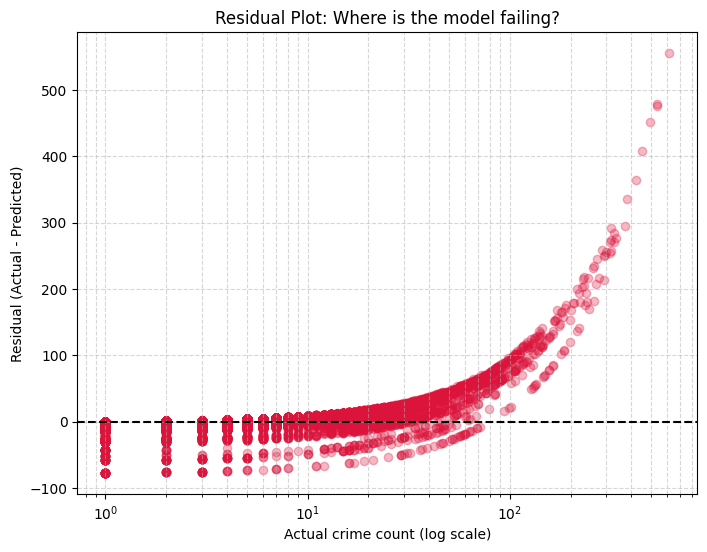

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


residuals = y_test - preds

plt.figure(figsize=(8, 6))
# Plot residuals against actual values
plt.scatter(y_test, residuals, alpha=0.3, color='crimson')

# Add a horizontal line at 0 (perfect prediction)
plt.axhline(0, color='black', linestyle='--')

plt.xscale("log")  # Keep log scale for x if actual values span magnitudes
plt.xlabel("Actual crime count (log scale)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot: Where is the model failing?")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

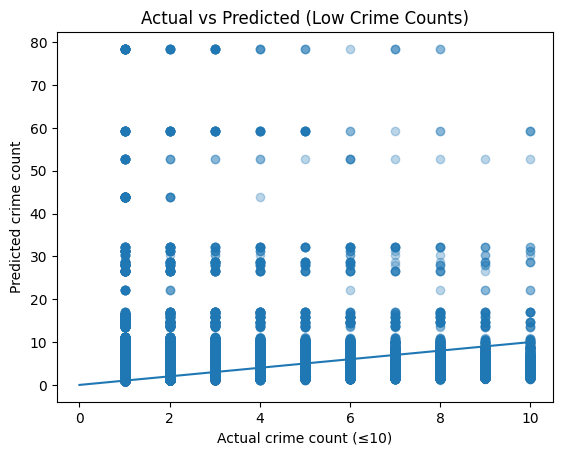

In [21]:
mask = y_test <= 10

plt.figure()
plt.scatter(y_test[mask], preds[mask], alpha=0.3)
plt.plot([0,10], [0,10])
plt.xlabel("Actual crime count (≤10)")
plt.ylabel("Predicted crime count")
plt.title("Actual vs Predicted (Low Crime Counts)")
plt.show()

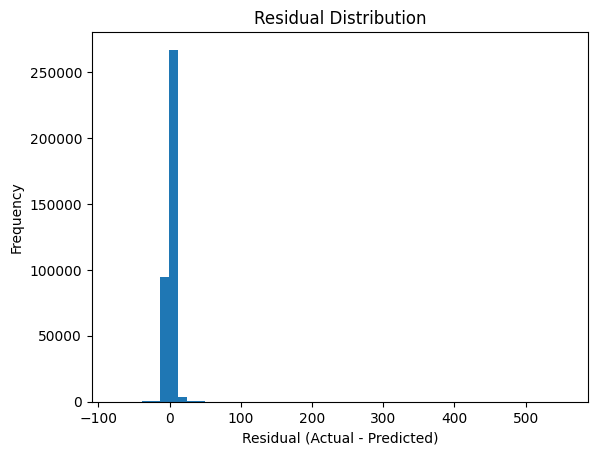

In [13]:
residuals = y_test - preds

plt.figure()
plt.hist(residuals, bins=50)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

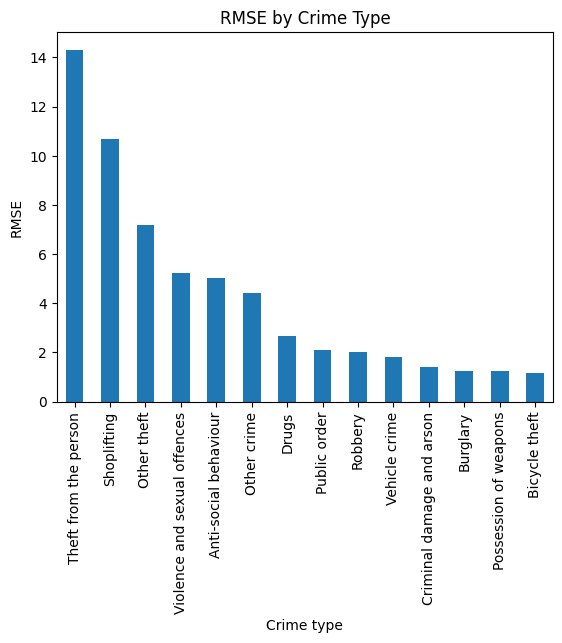

In [17]:
results = test.copy()
results["preds"] = preds

rmse_by_type = (
    results.groupby("Crime type")
    .apply(lambda x: np.sqrt(mean_squared_error(x["crime_count"], x["preds"])))
    .sort_values(ascending=False)
)

plt.figure()
rmse_by_type.plot(kind="bar")
plt.ylabel("RMSE")
plt.title("RMSE by Crime Type")
plt.show()

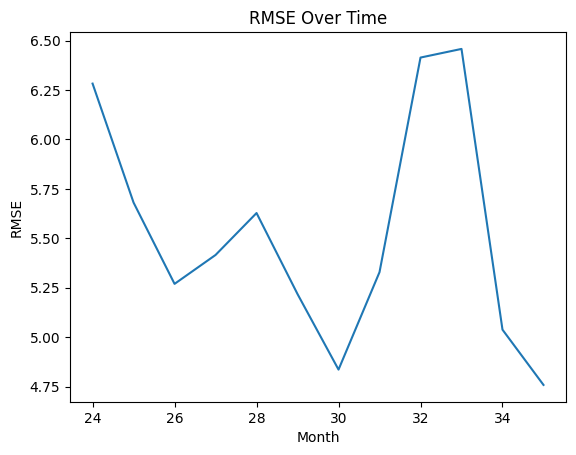

In [18]:
rmse_by_month = (
    results.groupby("Month")
    .apply(lambda x: np.sqrt(mean_squared_error(x["crime_count"], x["preds"])))
)

plt.figure()
rmse_by_month.plot()
plt.ylabel("RMSE")
plt.title("RMSE Over Time")
plt.show()